In [5]:
import pandas as pd

df = pd.read_csv("telecomx_latam_limpio.csv")

# eliminar churn vacíos
df = df.dropna(subset=["churn"])

df.shape
df.head()

,customerid,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total,cuentas_diarias
0,0002-orfbo,0.0,female,0,1,1,9,1,0.0,dsl,...,0.0,1.0,1.0,0.0,one year,1,mailed check,65.6,593.30,2.186667
1,0003-mknfe,0.0,male,0,0,0,9,1,1.0,dsl,...,0.0,0.0,0.0,1.0,month-to-month,0,mailed check,59.9,542.40,1.996667
2,0004-tlhlj,1.0,male,0,0,0,4,1,0.0,fiber optic,...,1.0,0.0,0.0,0.0,month-to-month,1,electronic check,73.9,280.85,2.463333
3,0011-igkff,1.0,male,1,1,0,13,1,0.0,fiber optic,...,1.0,0.0,1.0,1.0,month-to-month,1,electronic check,98.0,1237.85,3.266667
4,0013-exchz,1.0,female,1,1,0,3,1,0.0,fiber optic,...,0.0,1.0,1.0,0.0,month-to-month,1,mailed check,83.9,267.40,2.796667


In [6]:
df = df.drop(columns=["customerid","cuentas_diarias"])

df.columns

Index(['churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly', 'account_charges_total'],
      dtype='object')

In [8]:
categorical_cols = df.select_dtypes(include="object").columns

categorical_cols

Index(['customer_gender', 'internet_internetservice', 'account_contract',
       'account_paymentmethod'],
      dtype='object')

In [9]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

df_encoded.head()

,churn,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_onlinesecurity,internet_onlinebackup,internet_deviceprotection,...,account_charges_monthly,account_charges_total,customer_gender_male,internet_internetservice_fiber optic,internet_internetservice_no,account_contract_one year,account_contract_two year,account_paymentmethod_credit card (automatic),account_paymentmethod_electronic check,account_paymentmethod_mailed check
0,0.0,0,1,1,9,1,0.0,0.0,1.0,0.0,...,65.6,593.30,False,False,False,True,False,False,False,True
1,0.0,0,0,0,9,1,1.0,0.0,0.0,0.0,...,59.9,542.40,True,False,False,False,False,False,False,True
2,1.0,0,0,0,4,1,0.0,0.0,0.0,1.0,...,73.9,280.85,True,True,False,False,False,False,True,False
3,1.0,1,1,0,13,1,0.0,0.0,1.0,1.0,...,98.0,1237.85,True,True,False,False,False,False,True,False
4,1.0,1,1,0,3,1,0.0,0.0,0.0,0.0,...,83.9,267.40,False,True,False,False,False,False,False,True


In [10]:
churn_counts = df_encoded["churn"].value_counts()

print(churn_counts)

print("\nProporción:")
print(churn_counts / len(df_encoded))

churn
0.0    5174
1.0    1869
Name: count, dtype: int64

Proporción:
churn
0.0    0.73463
1.0    0.26537
Name: count, dtype: float64


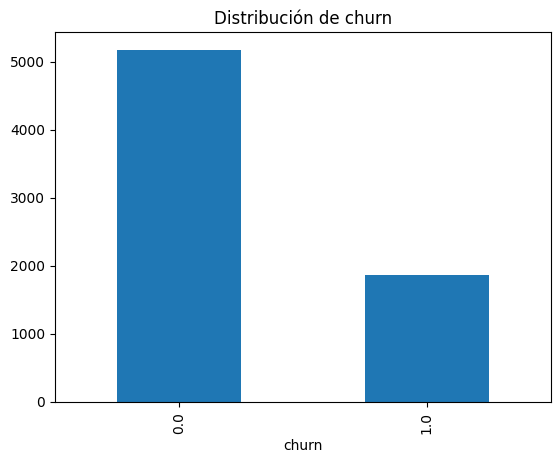

In [11]:
import matplotlib.pyplot as plt

churn_counts.plot(kind="bar")
plt.title("Distribución de churn")
plt.show()

In [13]:
df_encoded.isna().sum().sort_values(ascending=False).head(10)

,0
internet_onlinesecurity,1526
internet_techsupport,1526
internet_deviceprotection,1526
internet_streamingmovies,1526
internet_streamingtv,1526
internet_onlinebackup,1526
phone_multiplelines,682
account_charges_total,11
customer_tenure,0
phone_phoneservice,0


In [14]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

df_encoded_imputed = pd.DataFrame(
    imputer.fit_transform(df_encoded),
    columns=df_encoded.columns
)

df_encoded_imputed.isna().sum().sum()

np.int64(0)

In [15]:
from imblearn.over_sampling import SMOTE

X = df_encoded_imputed.drop("churn", axis=1)
y = df_encoded_imputed["churn"]

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("Antes:")
print(y.value_counts())

print("\nDespués:")
print(pd.Series(y_resampled).value_counts())

Antes:
churn
0.0    5174
1.0    1869
Name: count, dtype: int64

Después:
churn
0.0    5174
1.0    5174
Name: count, dtype: int64


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_resampled)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

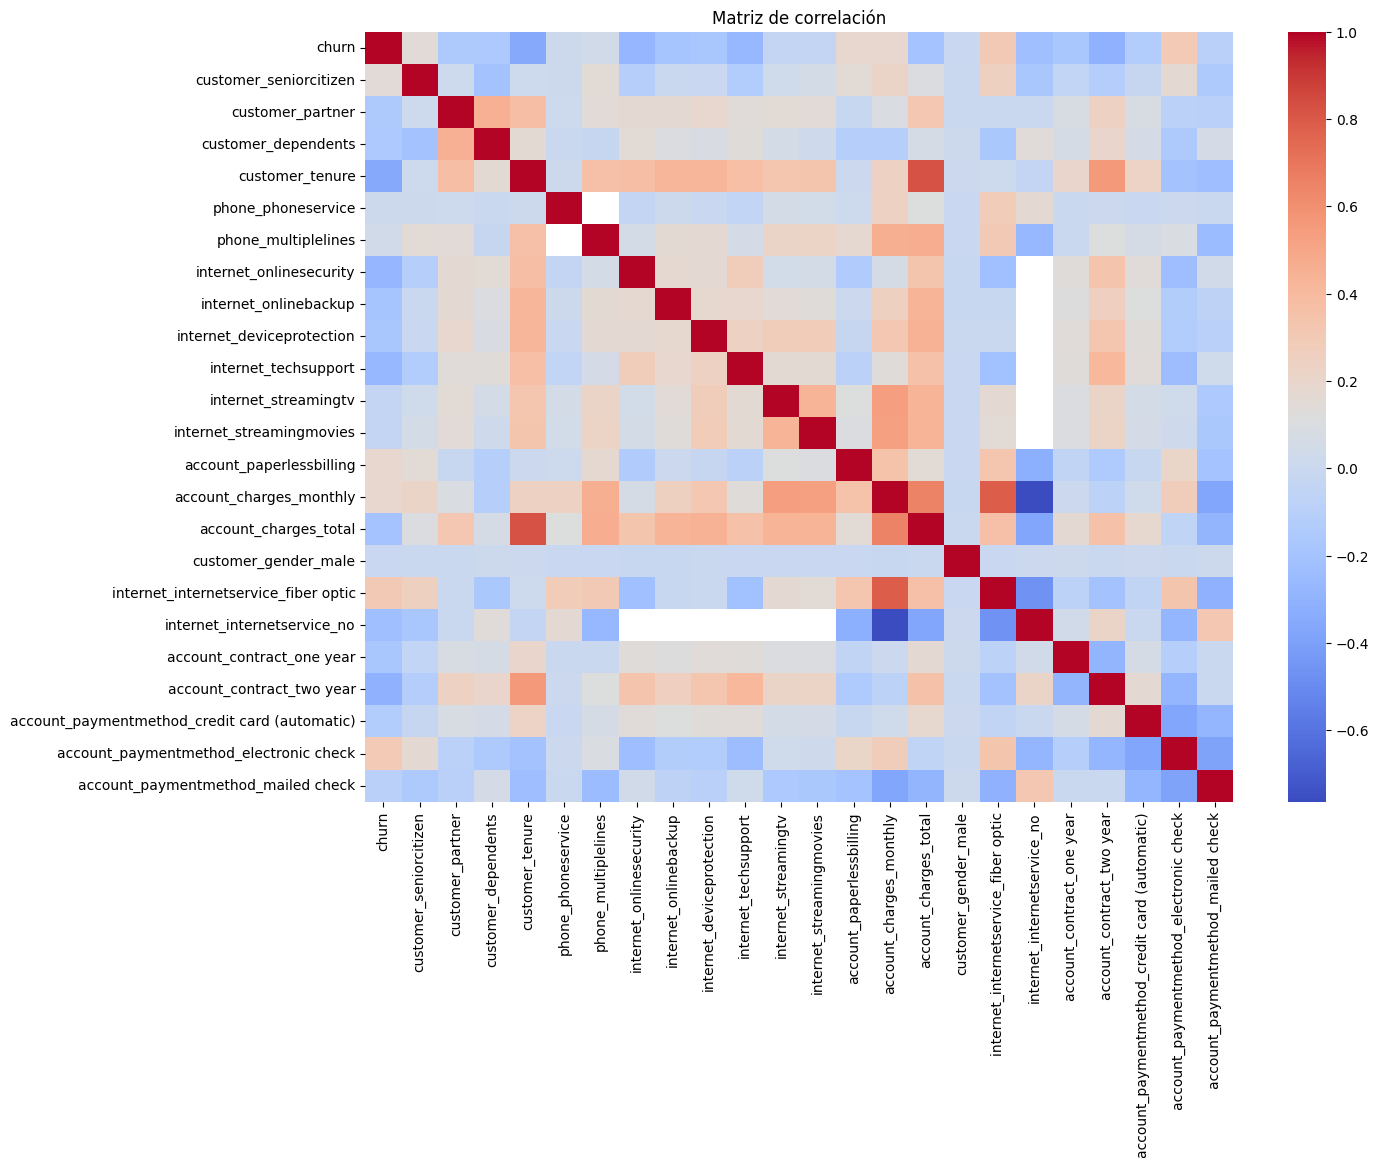

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_encoded.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

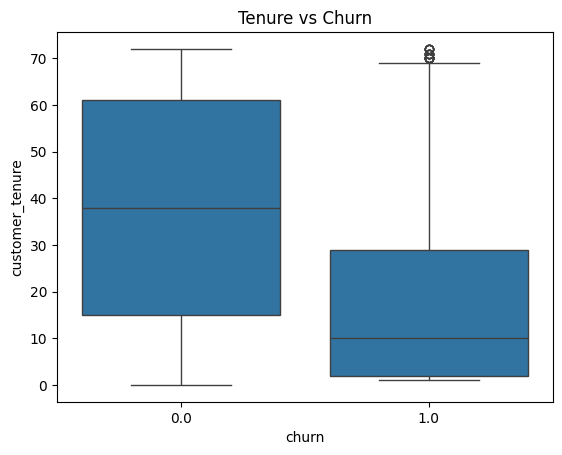

In [19]:
sns.boxplot(data=df, x="churn", y="customer_tenure")
plt.title("Tenure vs Churn")
plt.show()

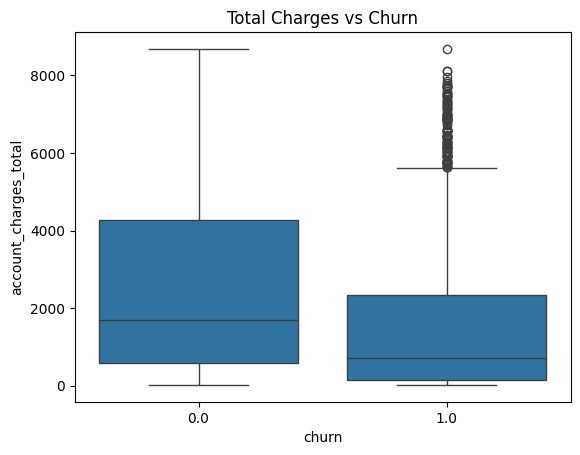

In [20]:
sns.boxplot(data=df, x="churn", y="account_charges_total")
plt.title("Total Charges vs Churn")
plt.show()

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_resampled,
    test_size=0.3,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(7243, 23)
(3105, 23)


In [22]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train,y_train)

y_pred_log = log_model.predict(X_test)

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train,y_train)

y_pred_rf = rf_model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [25]:
print("LOGISTIC REGRESSION")

print("Accuracy:",accuracy_score(y_test,y_pred_log))

print(confusion_matrix(y_test,y_pred_log))

print(classification_report(y_test,y_pred_log))

LOGISTIC REGRESSION
Accuracy: 0.762962962962963
[[1141  447]
 [ 289 1228]]
              precision    recall  f1-score   support

         0.0       0.80      0.72      0.76      1588
         1.0       0.73      0.81      0.77      1517

    accuracy                           0.76      3105
   macro avg       0.77      0.76      0.76      3105
weighted avg       0.77      0.76      0.76      3105



In [26]:
print("RANDOM FOREST")

print("Accuracy:",accuracy_score(y_test,y_pred_rf))

print(confusion_matrix(y_test,y_pred_rf))

print(classification_report(y_test,y_pred_rf))

RANDOM FOREST
Accuracy: 0.8570048309178744
[[1409  179]
 [ 265 1252]]
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.86      1588
         1.0       0.87      0.83      0.85      1517

    accuracy                           0.86      3105
   macro avg       0.86      0.86      0.86      3105
weighted avg       0.86      0.86      0.86      3105



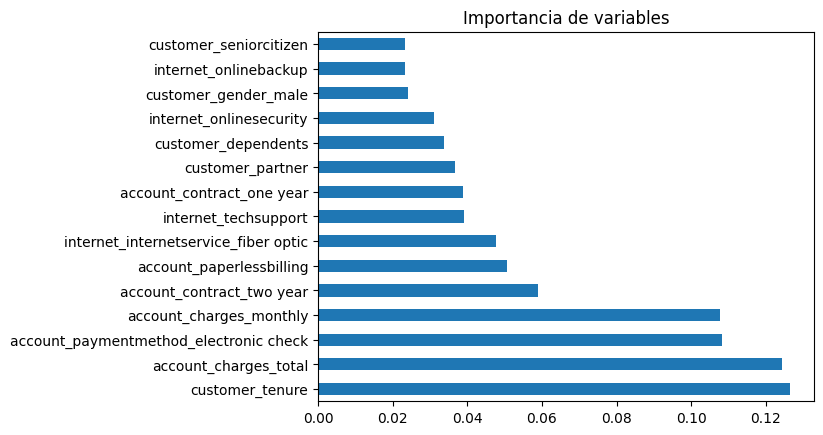

In [27]:
import pandas as pd

importances = rf_model.feature_importances_

feat_importance = pd.Series(importances,index=X.columns)

top_features = feat_importance.sort_values(ascending=False).head(15)

top_features.plot(kind="barh")
plt.title("Importancia de variables")
plt.show()

In [28]:
coefficients = pd.Series(
    log_model.coef_[0],
    index=X.columns
)

coefficients.sort_values(ascending=False).head(10)

,0
account_charges_total,1.047971
internet_internetservice_fiber optic,0.465093
account_paymentmethod_electronic check,0.203147
account_paperlessbilling,0.183671
internet_streamingtv,0.148999
phone_multiplelines,0.142880
internet_streamingmovies,0.141595
customer_seniorcitizen,0.081640
account_paymentmethod_mailed check,0.030424
customer_gender_male,0.010800


#Conclusión

##Factores más influyentes en churn:

- Tipo de contrato
- Meses de permanencia
- Cargos mensuales
- Método de pago
- Servicios adicionales

##Analisis:

- Clientes con contratos mes a mes presentan mayor probabilidad de cancelar el servicio en comparación con contratos de uno o dos años
- Los clientes con poco tiempo de permanencia muestran mayor tendencia a abandonar el servicio
- Los cargos mensuales altos están asociados con un mayor riesgo de churn
- Los métodos de pago automáticos presentan menor tasa de cancelación
- Los clientes que no cuentan con servicios adicionales tienen mayor probabilidad de cancelar el servicio

##Estrategias:

- Incentivar contratos anuales o de dos años mediante descuentos o beneficios adicionales
- Promover el uso de pagos automáticos
- Crear programas de fidelización durante los primeros meses de servicio
- Ofrecer paquetes de servicios adicionales para dar valor al cliente